In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
filename = 'heart.csv'
df = pd.read_csv(filename)
df.head(1)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0


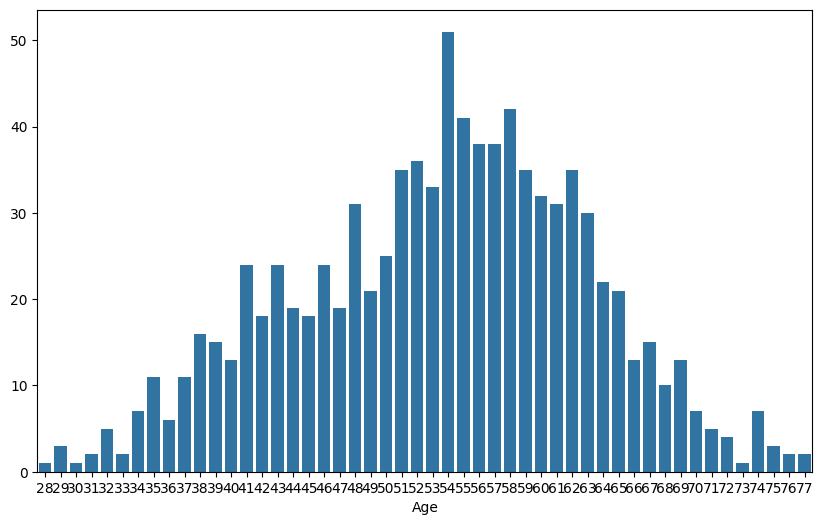

In [3]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Age'].value_counts().index, y=df['Age'].value_counts().values)
plt.show()

In [4]:
# chest pain type vs heart disease
data_chest_pain = df.groupby(['ChestPainType', 'HeartDisease']).size().reset_index(name='count')
data_chest_pain

,ChestPainType,HeartDisease,count
0,ASY,0,104
1,ASY,1,392
2,ATA,0,149
3,ATA,1,24
4,NAP,0,131
5,NAP,1,72
6,TA,0,26
7,TA,1,20


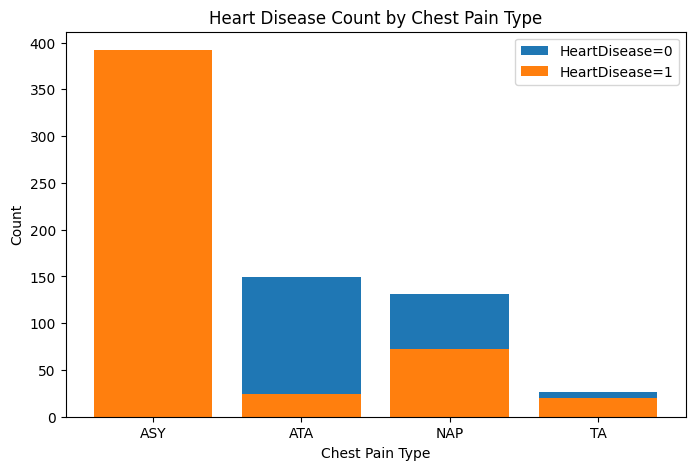

In [5]:
plt.figure(figsize=(8,5))
for disease_status in data_chest_pain['HeartDisease'].unique():
    subset = data_chest_pain[data_chest_pain['HeartDisease'] == disease_status]
    plt.bar(subset['ChestPainType'], subset['count'], label=f'HeartDisease={disease_status}')

plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.title('Heart Disease Count by Chest Pain Type')
plt.legend()
plt.show()

In [6]:
# restingECG to heart diseases
data_resting_ecg = df.groupby(['RestingECG', 'HeartDisease']).size().reset_index(name='count')
data_resting_ecg

,RestingECG,HeartDisease,count
0,LVH,0,82
1,LVH,1,106
2,Normal,0,267
3,Normal,1,285
4,ST,0,61
5,ST,1,117


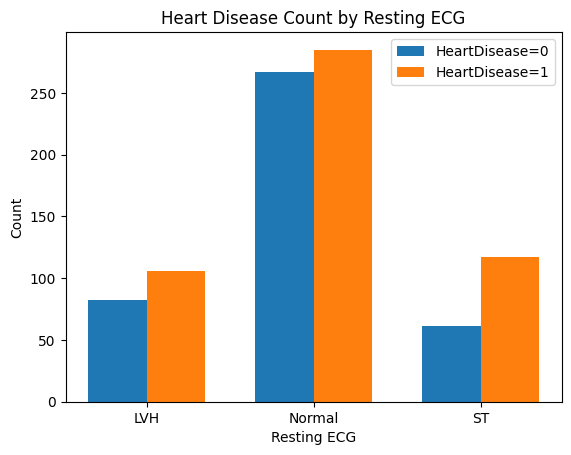

In [7]:
ecg_types = data_resting_ecg['RestingECG'].unique()
x = np.arange(len(ecg_types))
width = 0.35

subset_0 = data_resting_ecg[data_resting_ecg['HeartDisease'] == 0].set_index('RestingECG')['count']
subset_1 = data_resting_ecg[data_resting_ecg['HeartDisease'] == 1].set_index('RestingECG')['count']

plt.bar(x - width/2, subset_0.reindex(ecg_types, fill_value=0), width, label='HeartDisease=0')
plt.bar(x + width/2, subset_1.reindex(ecg_types, fill_value=0), width, label='HeartDisease=1')

plt.xlabel('Resting ECG')
plt.ylabel('Count')
plt.title('Heart Disease Count by Resting ECG')
plt.xticks(x, ecg_types)
plt.legend()
plt.show()

In [8]:
# ST_Slope to heart diseases
data_stslope = df.groupby(['ST_Slope' ,'HeartDisease']).size().reset_index(name='count')
data_stslope

,ST_Slope,HeartDisease,count
0,Down,0,14
1,Down,1,49
2,Flat,0,79
3,Flat,1,381
4,Up,0,317
5,Up,1,78


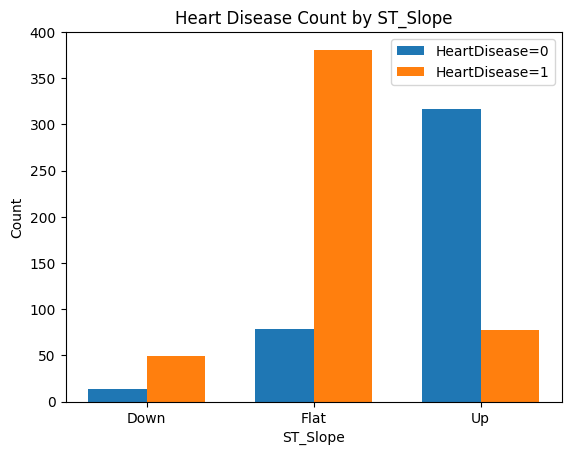

In [9]:
slopes = data_stslope['ST_Slope'].unique()
x = np.arange(len(slopes))
width = 0.35

subset_0 = data_stslope[data_stslope['HeartDisease'] == 0].set_index('ST_Slope')['count']
subset_1 = data_stslope[data_stslope['HeartDisease'] == 1].set_index('ST_Slope')['count']

plt.bar(x - width/2, subset_0.reindex(slopes, fill_value=0), width, label='HeartDisease=0')
plt.bar(x + width/2, subset_1.reindex(slopes, fill_value=0), width, label='HeartDisease=1')

plt.xlabel('ST_Slope')
plt.ylabel('Count')
plt.title('Heart Disease Count by ST_Slope')
plt.xticks(x, slopes)
plt.legend()
plt.show()

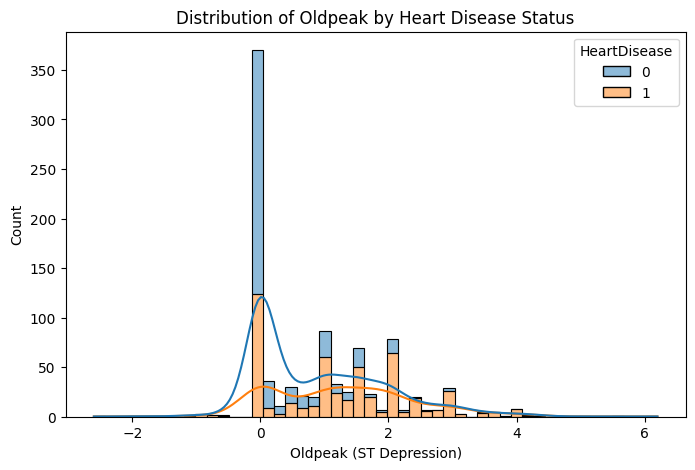

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Oldpeak', bins=50, kde=True, hue='HeartDisease', multiple='stack')
plt.title('Distribution of Oldpeak by Heart Disease Status')
plt.xlabel('Oldpeak (ST Depression)')
plt.ylabel('Count')
plt.show()

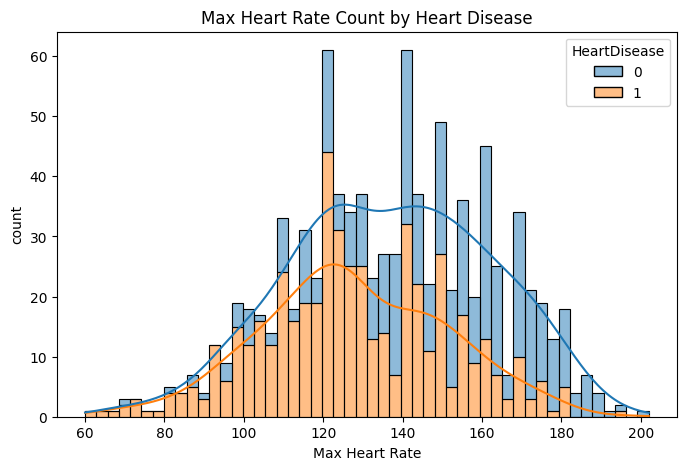

In [11]:
# max heart to heart disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MaxHR', bins=50, hue='HeartDisease', multiple='stack', kde=True)
plt.title('Max Heart Rate Count by Heart Disease')
plt.xlabel('Max Heart Rate')
plt.ylabel('count')
plt.show()

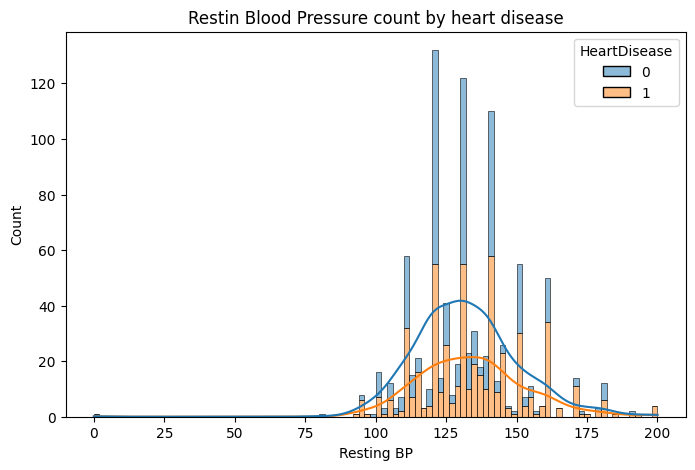

In [12]:
# resting bp to heart disease
plt.figure(figsize = (8,5))
sns.histplot(data=df, x='RestingBP', bins=100, hue='HeartDisease', multiple='stack', kde=True)
plt.title('Restin Blood Pressure count by heart disease')
plt.xlabel('Resting BP')
plt.ylabel('Count')
plt.show()

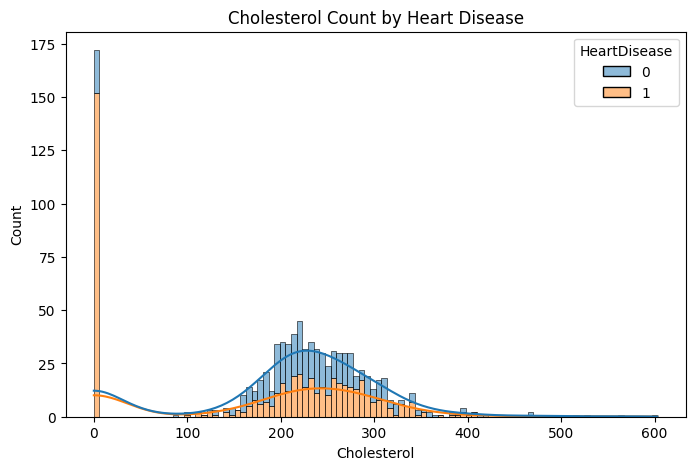

In [13]:
# cholesterol to heart disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Cholesterol', bins=100, hue='HeartDisease', multiple='stack', kde=True)
plt.title('Cholesterol Count by Heart Disease')
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.show()

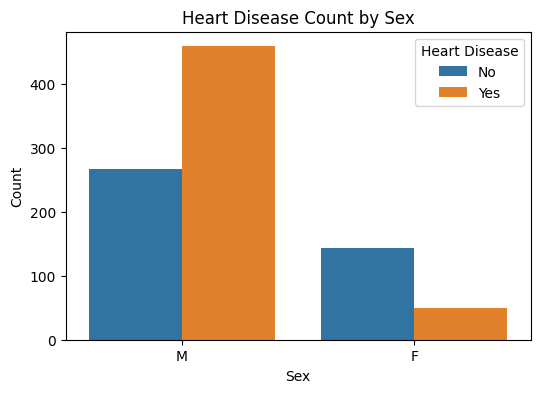

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='HeartDisease')
plt.title('Heart Disease Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

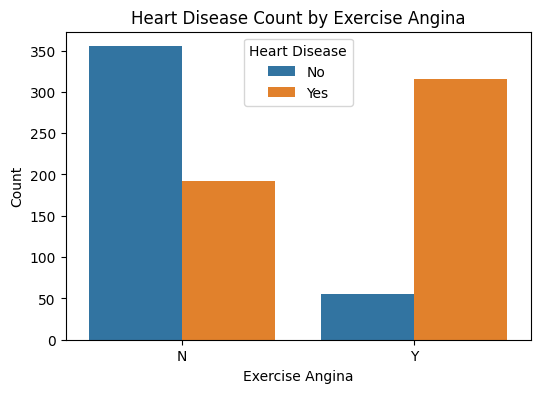

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease')
plt.title('Heart Disease Count by Exercise Angina')
plt.xlabel('Exercise Angina')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

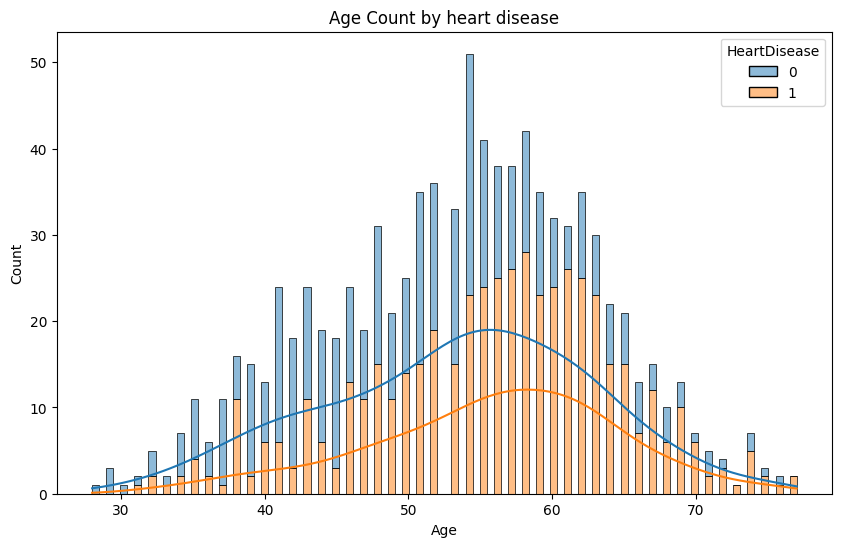

In [16]:
# age to heart disease
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', bins=100, hue='HeartDisease', multiple='stack', kde=True)
plt.title('Age Count by heart disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()